# ProbitBART

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import genbart as gb

In [2]:
conf_color = '#227018'
fill_color = '#44f02e'

plt.style.use("bart_style.mplstyle")
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## 1d Example

In [3]:
n_points = 100
x_true = np.linspace(0, 10, n_points)
y = np.where(x_true < 5, 0, 1)
x = x_true + np.random.rand(n_points)

In [4]:
model_10 = gb.ProbitBart(m=10).fit(x, y)

In [5]:
model_100 = gb.ProbitBart(m=100, n_burn=200, n_samples=500).fit(x, y)

In [6]:
model_200 = gb.ProbitBart(m=200, n_burn=200, n_samples=500).fit(x, y)

In [7]:
y_bart = []

y_bart.append(model_10.predict_probs(x_true))
y_bart.append(model_100.predict_probs(x_true))
y_bart.append(model_200.predict_probs(x_true))

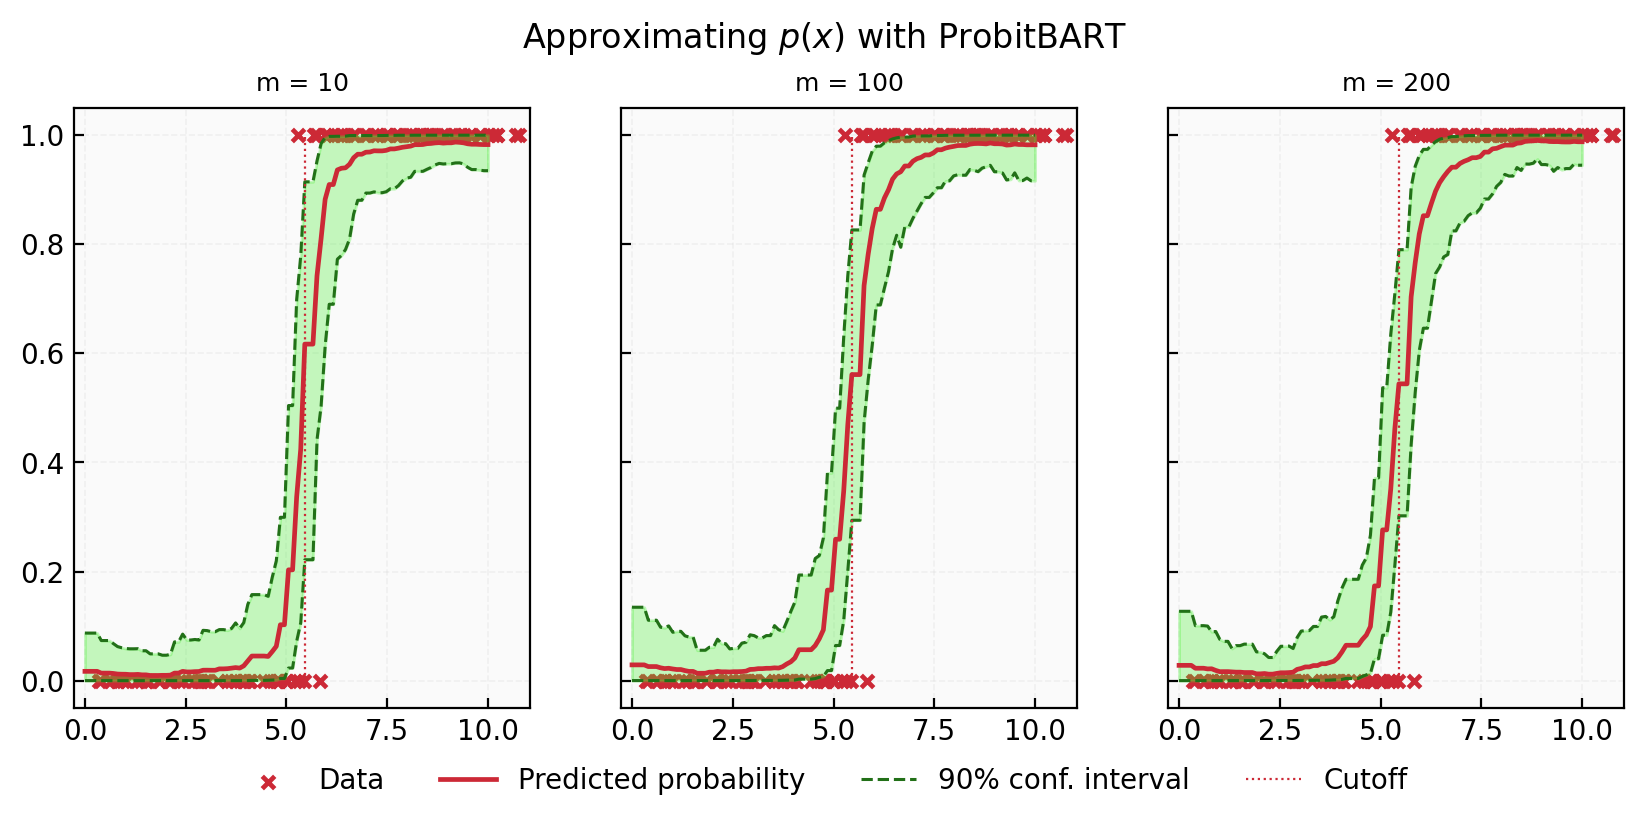

In [9]:
m = [10, 100, 200]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharey=True, dpi=200)
for i in range(len(y_bart)):
    axes[i].scatter(x, y, marker='x', s=20.0, label=r"Data")
    axes[i].plot(x_true, y_bart[i]["probs"], label="Predicted probability")
    axes[i].plot(x_true, y_bart[i]["conf_int_low"], ls='--', lw=1.1,  c=conf_color, label="90% conf. interval")
    axes[i].plot(x_true, y_bart[i]["conf_int_high"], ls='--', lw=1.1, c=conf_color)
    axes[i].fill_between(x_true, y_bart[i]["conf_int_low"], y_bart[i]["conf_int_high"], color=fill_color, alpha=0.3)
    axes[i].vlines(x_true[np.argmax(y_bart[i]["probs"]>0.5)], 0, 1, ls=':', lw=0.8, label="Cutoff")
    axes[i].set_title(f"m = {m[i]}", fontsize=9)
    
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=4)

fig.suptitle("Approximating $p(x)$ with ProbitBART", fontsize=12)

plt.subplots_adjust(bottom=0.12)
plt.subplots_adjust(top=0.87)
plt.show()

## 2d Example

In [3]:
n_sample = 100
X = np.random.uniform([-5, -5], [5, 5], size=(n_sample, 2))
y = ((X[:, 0]**2 + X[:, 1]**2) + 2*np.random.randn(n_sample) <= 4).astype(int)

In [4]:
model_2d = gb.ProbitBart().fit(X, y)

In [5]:
plot_x = np.linspace(-5, 5, 100)
xx, yy = np.meshgrid(plot_x, plot_x)
z = ((xx**2+ yy**2) <= 4).astype(int)
pred_z = model_2d.predict_probs(np.column_stack((xx.ravel(), yy.ravel())))

In [6]:
pred_p = pred_z["probs"].reshape(xx.shape)
low_conf_ints = pred_z["conf_int_low"].reshape(xx.shape)
high_conf_ints = pred_z["conf_int_high"].reshape(xx.shape)
conf_ints_width = high_conf_ints - low_conf_ints

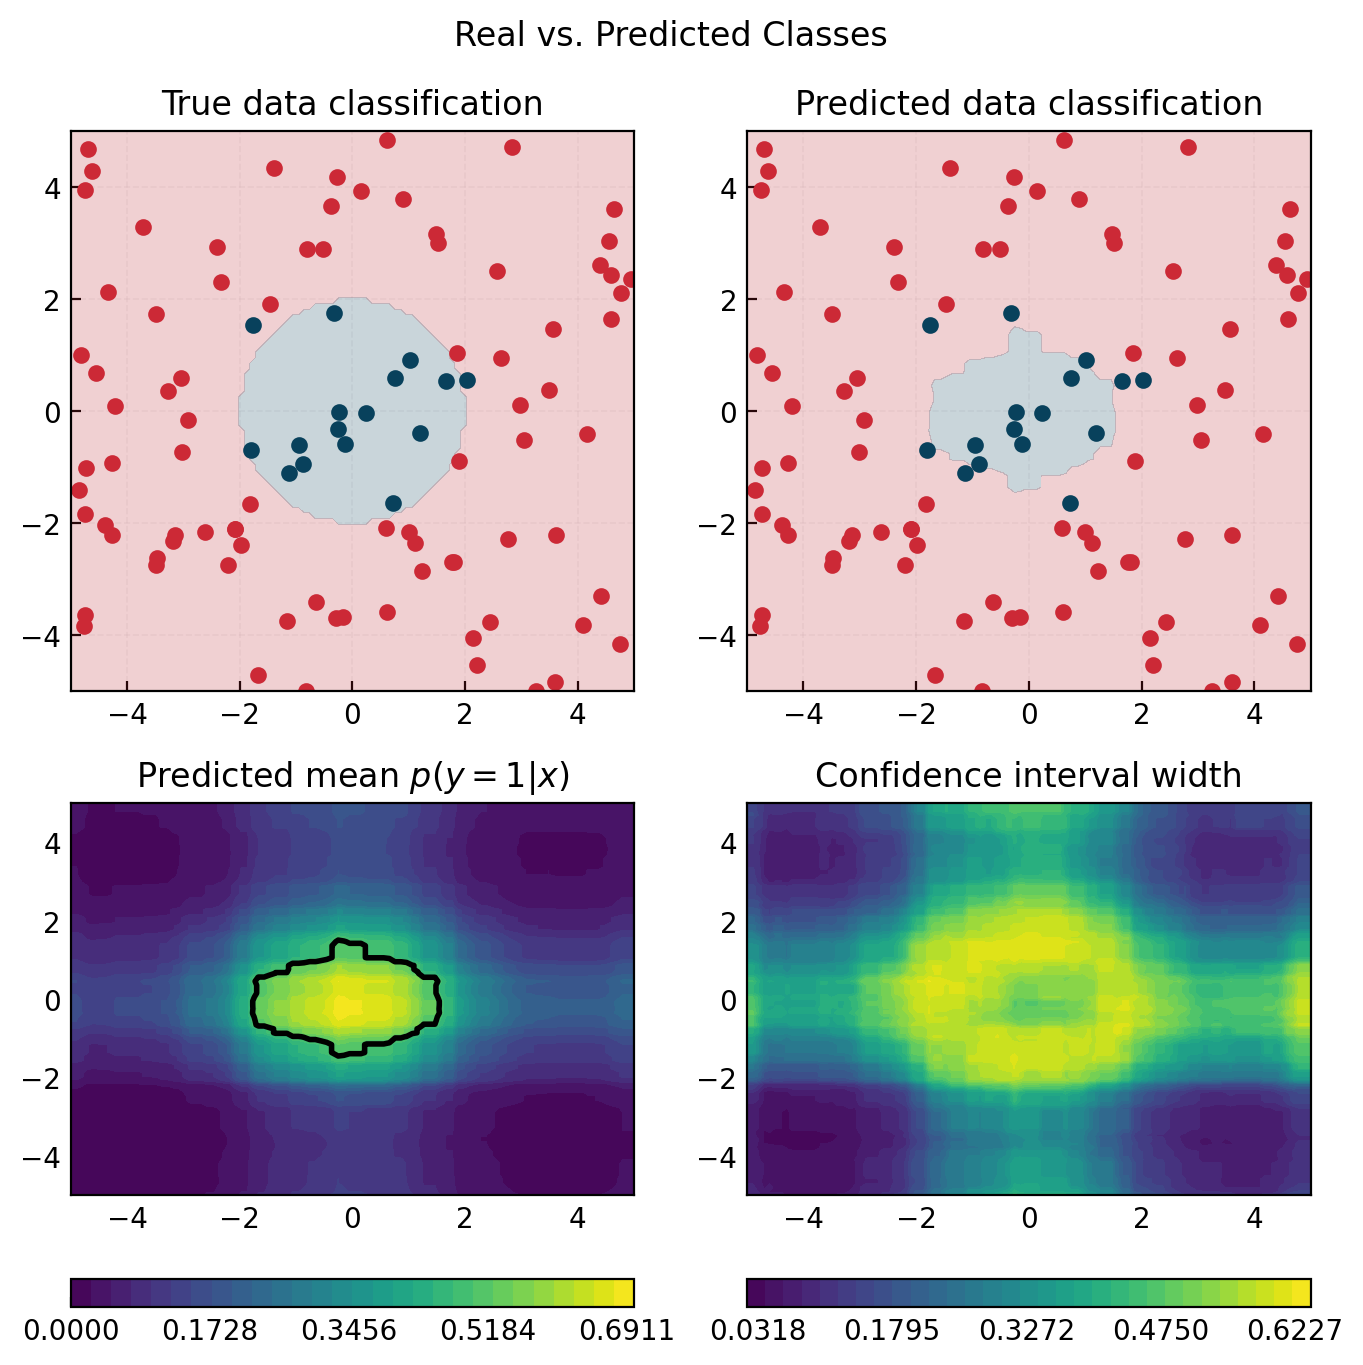

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), dpi=200)

#real classes
mask = (y == 0)
axes[0, 0].contourf(xx, yy, z,levels=[-0.5, 0.5, 1.5],colors=[colors[0], colors[1]],alpha=0.2)
axes[0, 0].scatter(X[mask, 0], X[mask, 1], color=colors[0])
axes[0, 0].scatter(X[~mask, 0], X[~mask, 1], color=colors[1])
axes[0, 0].set_title("True data classification")

#predicted classes
axes[0, 1].contourf(xx, yy, pred_p,levels=[-0.5, 0.5, 1.5],colors=[colors[0], colors[1]],alpha=0.2)
axes[0, 1].scatter(X[mask, 0], X[mask, 1], color=colors[0])
axes[0, 1].scatter(X[~mask, 0], X[~mask, 1], color=colors[1])
axes[0, 1].set_title("Predicted data classification")

#predicted p heatmap
p_hm = axes[1, 0].contourf(xx, yy, pred_p, levels=30)
axes[1, 0].contour(xx, yy, pred_p, levels=[0.5], colors="k", linewidths=2)
p_col = fig.colorbar(p_hm, ax=axes[1, 0], orientation="horizontal")
p_col.set_ticks(np.linspace(0.0, pred_p.max(), 5))
axes[1, 0].set_title(r"Predicted mean $p(y=1|x)$")

#uncertainty heatmap
hm_w = axes[1, 1].contourf(xx, yy, conf_ints_width, levels=30)
conf_col = fig.colorbar(hm_w, ax=axes[1, 1], orientation="horizontal")
conf_col.set_ticks(np.linspace(conf_ints_width.min(), conf_ints_width.max(), 5))
axes[1, 1].set_title("Confidence interval width")

fig.suptitle("Real vs. Predicted Classes", y=0.95)

plt.show()